# 1. Import and Install Dependencies

In [1]:
!pip install tensorflow==2.19.0 opencv-python mediapipe==0.10.7 scikit-learn matplotlib


[notice] A new release of pip is available: 25.2 -> 26.0
[notice] To update, run: C:\Users\nduha\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import tensorflow as tf
import mediapipe as mp
import cv2

print("TF version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))


TF version: 2.19.0
GPU: []


In [3]:
import cv2
import numpy as np
import os
from matplotlib import pyplot as plt
import time
import mediapipe as mp

# 2. Keypoints using MP Holistic

In [4]:
mp_holistic = mp.solutions.holistic # Holistic model
mp_drawing = mp.solutions.drawing_utils # Drawing utilities

In [5]:
def mediapipe_detection(image, model):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # COLOR CONVERSION BGR 2 RGB
    image.flags.writeable = False                  # Image is no longer writeable
    results = model.process(image)                 # Make prediction
    image.flags.writeable = True                   # Image is now writeable 
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR) # COLOR COVERSION RGB 2 BGR
    return image, results

In [6]:
def draw_landmarks(image, results):
    mp_drawing.draw_landmarks(image, results.face_landmarks, mp_holistic.FACEMESH_TESSELATION) # Draw face connections
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS) # Draw pose connections
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS) # Draw left hand connections
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS) # Draw right hand connections

In [7]:
def draw_styled_landmarks(image, results):
    # Draw face connections
    mp_drawing.draw_landmarks(image, results.face_landmarks, mp_holistic.FACEMESH_TESSELATION, 
                             mp_drawing.DrawingSpec(color=(80,110,10), thickness=1, circle_radius=1), 
                             mp_drawing.DrawingSpec(color=(80,256,121), thickness=1, circle_radius=1)
                             ) 
    # Draw pose connections
    mp_drawing.draw_landmarks(image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS,
                             mp_drawing.DrawingSpec(color=(80,22,10), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(80,44,121), thickness=2, circle_radius=2)
                             ) 
    # Draw left hand connections
    mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                             mp_drawing.DrawingSpec(color=(121,22,76), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(121,44,250), thickness=2, circle_radius=2)
                             ) 
    # Draw right hand connections  
    mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                             mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=4), 
                             mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2)
                             ) 

In [8]:
cap = cv2.VideoCapture(0)
# Set mediapipe model 
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    while cap.isOpened():

        # Read feed
        ret, frame = cap.read()

        # Make detections
        image, results = mediapipe_detection(frame, holistic)
        print(results)
        
        # Draw landmarks
        draw_styled_landmarks(image, results)

        # Show to screen
        cv2.imshow('OpenCV Feed', image)

        # Break gracefully
        if cv2.waitKey(10) & 0xFF == ord('q'):
            break
    cap.release()
    cv2.destroyAllWindows()

<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.soluti

In [9]:
draw_landmarks(frame, results)

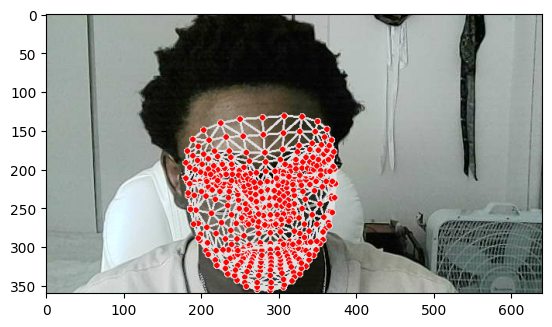

In [10]:
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

# 3. Extract Keypoint Values

In [11]:
len(results.face_landmarks.landmark)

468

In [12]:
pose = []
for res in results.pose_landmarks.landmark:
    test = np.array([res.x, res.y, res.z, res.visibility])
    pose.append(test)

In [13]:
pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(132)
face = np.array([[res.x, res.y, res.z] for res in results.face_landmarks.landmark]).flatten() if results.face_landmarks else np.zeros(1404)
lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)

In [14]:
face = np.array([[res.x, res.y, res.z] for res in results.face_landmarks.landmark]).flatten() if results.face_landmarks else np.zeros(1404)


In [15]:
def extract_keypoints(results):
    pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(33*4)
    face = np.array([[res.x, res.y, res.z] for res in results.face_landmarks.landmark]).flatten() if results.face_landmarks else np.zeros(468*3)
    lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
    rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)
    return np.concatenate([pose, face, lh, rh])

In [16]:
result_test = extract_keypoints(results)

In [17]:
result_test

array([ 0.42893156,  0.71935016, -2.25874448, ...,  0.        ,
        0.        ,  0.        ])

In [18]:
#np.save('0', result_test)

In [19]:
#np.load('0.npy')

# 4. Setup Folders for Collection

In [20]:
# Path for exported data, numpy arrays
DATA_PATH = os.path.join('MP_Data') 

# Actions that we try to detect
actions = np.array(['hello', 'thanks', 'iloveyou', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9'])

# Sixty videos worth of data
no_sequences = 60

# Videos are going to be 30 frames in length
sequence_length = 30

# Folder start
start_folder = 0

In [21]:
for action in actions: 
    for sequence in range(no_sequences):
        try: 
            os.makedirs(os.path.join(DATA_PATH, action, str(sequence)))
        except:
            pass

In [22]:
#for action in actions: 
#    dirmax = np.max(np.array(os.listdir(os.path.join(DATA_PATH, action))).astype(int))
#    for sequence in range(1,no_sequences+1):
#        try: 
#            os.makedirs(os.path.join(DATA_PATH, action, str(dirmax+sequence)))
#        except:
#            pass

# 5. Collect Keypoint Values for Training and Testing

In [23]:
cap = cv2.VideoCapture(0)
# Set mediapipe model 
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    
    # Add pause and skip state variables
    paused = False
    skip_action = False
    
    print(f"Starting collection for {len(actions)} actions: {', '.join(actions)}")
    print(f"Each action will have {no_sequences} sequences of {sequence_length} frames")
    
    # NEW LOOP - Loop through all 13 actions
    for action in actions:
        # Reset skip flag for each new action
        skip_action = False
        
        # ALWAYS show prompt before each action (regardless of existing data)
        print(f"\n{'='*50}")
        print(f"NEXT ACTION: {action}")
        print(f"{'='*50}")
        
        # Check existing data count for this action
        existing_sequences = 0
        action_path = os.path.join(DATA_PATH, action)
        if os.path.exists(action_path):
            for item in os.listdir(action_path):
                item_path = os.path.join(action_path, item)
                if os.path.isdir(item_path) and item.isdigit():
                    frame_count = len([f for f in os.listdir(item_path) if f.endswith('.npy')])
                    if frame_count > 0:
                        existing_sequences += 1
        
        # Show action selection prompt (ALWAYS appears)
        while True:
            ret, frame = cap.read()
            
            # Display action info
            cv2.putText(frame, f"NEXT ACTION: {action}", (50, 50),
                       cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 255), 3, cv2.LINE_AA)
            
            # Show existing data status
            if existing_sequences > 0:
                status_text = f"Has {existing_sequences}/{no_sequences} sequences"
                status_color = (0, 255, 255)  # Yellow
            else:
                status_text = "No existing data"
                status_color = (255, 255, 255)  # White
            
            cv2.putText(frame, status_text, (50, 100),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, status_color, 2, cv2.LINE_AA)
            
            # Show options
            y_offset = 150
            
            # Always show 'c' (Continue)
            cv2.putText(frame, "Press 'c' to CONTINUE collecting", (50, y_offset),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2, cv2.LINE_AA)
            y_offset += 50
            
            # ALWAYS show 'o' (Overwrite) if there's ANY data (even partial)
            if existing_sequences > 0:
                cv2.putText(frame, "Press 'o' to OVERWRITE (delete all and start fresh)", (50, y_offset),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 165, 0), 2, cv2.LINE_AA)  # Orange
                y_offset += 50
            
            # Always show 's' (Skip)
            cv2.putText(frame, "Press 's' to SKIP to next action", (50, y_offset),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2, cv2.LINE_AA)
            y_offset += 50
            
            # Always show 'q' (Quit)
            cv2.putText(frame, "Press 'q' to QUIT", (50, y_offset),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2, cv2.LINE_AA)
            
            cv2.imshow('OpenCV Feed', frame)
            
            key = cv2.waitKey(10) & 0xFF
            
            if key == ord('c'):  # Continue collecting (resume where left off)
                print(f"Continuing with action '{action}'...")
                if existing_sequences > 0:
                    print(f"Will resume from sequence {existing_sequences}/{no_sequences}")
                break
            
            elif key == ord('o') and existing_sequences > 0:  # Overwrite if ANY data exists
                print(f"OVERWRITING existing data for '{action}'...")
                # DELETE existing data for this action
                import shutil
                if os.path.exists(action_path):
                    shutil.rmtree(action_path)
                    print(f"Deleted all data for '{action}'")
                # Recreate empty folder
                os.makedirs(action_path, exist_ok=True)
                existing_sequences = 0  # Reset count
                break
            
            elif key == ord('s'):  # Skip action
                skip_action = True
                print(f"Skipping action '{action}'")
                break
            
            elif key == ord('q'):  # Quit
                print("Quitting collection...")
                cap.release()
                cv2.destroyAllWindows()
                exit()
        
        if skip_action:
            print(f"\n--- Skipped action: {action} ---")
            continue  # Skip to next action
        
        print(f"\n{'='*50}")
        print(f"STARTING COLLECTION FOR ACTION: {action}")
        print(f"{'='*50}")
        
        # Loop through sequences 0 to (no_sequences-1)
        for sequence in range(no_sequences):
            # Get sequence path
            seq_path = os.path.join(DATA_PATH, action, str(sequence))
            
            # If we're continuing and sequence is already complete, skip it
            if existing_sequences > 0 and os.path.exists(seq_path):
                existing_frames = len([f for f in os.listdir(seq_path) if f.endswith('.npy')])
                if existing_frames >= sequence_length:
                    print(f"Sequence {sequence} already complete. Skipping...")
                    continue
            
            # Loop through video length aka sequence length
            for frame_num in range(sequence_length):
                # Skip frame if already exists (when resuming)
                frame_path = os.path.join(DATA_PATH, action, str(sequence), f"{frame_num}.npy")
                if os.path.exists(frame_path):
                    continue
                
                # Read feed
                ret, frame = cap.read()
                if not ret:
                    print("Failed to grab frame")
                    break
                
                # Display pause message if paused
                if paused:
                    cv2.putText(frame, 'PAUSED - Press P to Resume', (120, 200), 
                               cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 4, cv2.LINE_AA)
                    cv2.imshow('OpenCV Feed', frame)
                    
                    # Wait for key press while paused
                    key = cv2.waitKey(10) & 0xFF
                    if key == ord('p'):  # Resume if 'p' pressed
                        paused = False
                        print("Resuming collection...")
                        continue
                    elif key == ord('q'):  # Quit if 'q' pressed
                        print("Quitting collection...")
                        cap.release()
                        cv2.destroyAllWindows()
                        exit()
                    else:
                        continue

                # Make detections
                image, results = mediapipe_detection(frame, holistic)

                # Draw landmarks
                draw_styled_landmarks(image, results)
                
                # Show action name on screen
                cv2.putText(image, f'ACTION: {action}', (15, 12), 
                           cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1, cv2.LINE_AA)
                cv2.putText(image, f'Sequence: {sequence}/{no_sequences-1}', (15, 30), 
                           cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1, cv2.LINE_AA)
                cv2.putText(image, f'Frame: {frame_num+1}/{sequence_length}', (15, 48), 
                           cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1, cv2.LINE_AA)
                
                # NEW Apply wait logic for first frame
                if frame_num == 0: 
                    cv2.putText(image, 'STARTING COLLECTION', (120, 200), 
                               cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 4, cv2.LINE_AA)
                    # Show to screen
                    cv2.imshow('OpenCV Feed', image)
                    cv2.waitKey(500)
                else: 
                    # Show to screen
                    cv2.imshow('OpenCV Feed', image)
                
                # NEW Export keypoints (only if not paused)
                keypoints = extract_keypoints(results)
                npy_path = os.path.join(DATA_PATH, action, str(sequence), str(frame_num))
                
                # Ensure directory exists before saving
                os.makedirs(os.path.dirname(npy_path), exist_ok=True)
                np.save(npy_path, keypoints)
                
                # Progress indicator (less verbose)
                if frame_num == 0 or frame_num == sequence_length-1 or frame_num % 10 == 0:
                    print(f"  Action: {action}, Seq: {sequence}, Frame: {frame_num+1}/{sequence_length}")

                # Check for pause/quit/skip keys
                key = cv2.waitKey(10) & 0xFF
                if key == ord('p'):  # Pause if 'p' pressed
                    paused = True
                    print("Paused collection. Press P to resume.")
                    frame_num -= 1  # Stay on same frame number
                    continue
                elif key == ord('s'):  # Skip current action if 's' pressed
                    print(f"\nSkipping action '{action}'...")
                    skip_action = True
                    break  # Break out of sequence loop
                elif key == ord('q'):  # Quit if 'q' pressed
                    print("Quitting collection...")
                    cap.release()
                    cv2.destroyAllWindows()
                    exit()
            
            # If skip_action is True, break out of sequence loop
            if skip_action:
                break
        
        print(f"\n✓ Completed action: {action}")
        print(f"Progress: {actions.tolist().index(action) + 1}/{len(actions)} actions done")
                    
    cap.release()
    cv2.destroyAllWindows()
    print("\n" + "="*50)
    print("ALL ACTIONS COLLECTION COMPLETE!")
    print(f"Collected data for {len(actions)} actions:")
    for action in actions:
        action_path = os.path.join(DATA_PATH, action)
        if os.path.exists(action_path):
            seq_count = len([d for d in os.listdir(action_path) 
                           if os.path.isdir(os.path.join(action_path, d)) and d.isdigit()])
            print(f"  - {action}: {seq_count}/{no_sequences} sequences")
    print("="*50)

Starting collection for 13 actions: hello, thanks, iloveyou, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9
Each action will have 60 sequences of 30 frames

NEXT ACTION: hello
Skipping action 'hello'

--- Skipped action: hello ---

NEXT ACTION: thanks
Skipping action 'thanks'

--- Skipped action: thanks ---

NEXT ACTION: iloveyou
Skipping action 'iloveyou'

--- Skipped action: iloveyou ---

NEXT ACTION: 0
Skipping action '0'

--- Skipped action: 0 ---

NEXT ACTION: 1
OVERWRITING existing data for '1'...
Deleted all data for '1'

STARTING COLLECTION FOR ACTION: 1
  Action: 1, Seq: 0, Frame: 1/30
  Action: 1, Seq: 0, Frame: 11/30
  Action: 1, Seq: 0, Frame: 21/30
  Action: 1, Seq: 0, Frame: 30/30
  Action: 1, Seq: 1, Frame: 1/30
  Action: 1, Seq: 1, Frame: 11/30
  Action: 1, Seq: 1, Frame: 21/30
  Action: 1, Seq: 1, Frame: 30/30
  Action: 1, Seq: 2, Frame: 1/30
  Action: 1, Seq: 2, Frame: 11/30
  Action: 1, Seq: 2, Frame: 21/30
  Action: 1, Seq: 2, Frame: 30/30
  Action: 1, Seq: 3, Frame: 1/30
  Action: 1

In [24]:
cap.release()
cv2.destroyAllWindows()

# 6. Preprocess Data and Create Labels and Features

In [25]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

In [26]:
label_map = {label:num for num, label in enumerate(actions)}

In [27]:
label_map

{np.str_('hello'): 0,
 np.str_('thanks'): 1,
 np.str_('iloveyou'): 2,
 np.str_('0'): 3,
 np.str_('1'): 4,
 np.str_('2'): 5,
 np.str_('3'): 6,
 np.str_('4'): 7,
 np.str_('5'): 8,
 np.str_('6'): 9,
 np.str_('7'): 10,
 np.str_('8'): 11,
 np.str_('9'): 12}

In [28]:
sequences, labels = [], []
for action in actions:
    for sequence in np.array(os.listdir(os.path.join(DATA_PATH, action))).astype(int):
        window = []
        for frame_num in range(sequence_length):
            res = np.load(os.path.join(DATA_PATH, action, str(sequence), "{}.npy".format(frame_num)))
            window.append(res)
        sequences.append(window)
        labels.append(label_map[action])

In [29]:
np.array(sequences).shape

(780, 30, 1662)

In [30]:
np.array(labels).shape

(780,)

In [31]:
X = np.array(sequences)

In [32]:
X.shape

(780, 30, 1662)

In [33]:
y = to_categorical(labels).astype(int)

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05)

In [35]:
y_test.shape

(39, 13)

# 7. Build and Train LSTM Neural Network

In [ ]:
#del model

In [116]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Bidirectional, GRU
from tensorflow.keras.callbacks import TensorBoard, EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

In [117]:
log_dir = os.path.join('Logs')
tb_callback = TensorBoard(log_dir=log_dir)

In [118]:
# Callbacks (with ReduceLROnPlateau, NO learning rate schedule)
callbacks = [
    tb_callback,
    EarlyStopping(
        monitor='val_accuracy',
        patience=30,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.5,
        patience=15,
        min_lr=0.000001,
        verbose=1
    ),
    ModelCheckpoint(
        'best__numbers_model_2.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

In [119]:
# Load one sample to get the shape
sample = np.load(os.path.join(DATA_PATH, actions[0], '0', '0.npy'))
num_features = len(sample)  # This is your feature count

print(f"Number of features: {num_features}")

Number of features: 1662


In [120]:
model = Sequential([
    # Use Bidirectional LSTM for better temporal understanding
    Bidirectional(LSTM(256, return_sequences=True, 
                      kernel_regularizer=l2(0.001)),
                  input_shape=(sequence_length, num_features)),
    BatchNormalization(),
    Dropout(0.4),
    
    Bidirectional(LSTM(512, return_sequences=True,
                      kernel_regularizer=l2(0.001))),
    BatchNormalization(),
    Dropout(0.4),
    
    LSTM(256, return_sequences=False,
         kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.4),
    
    Dense(512, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.5),
    
    Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.5),
    
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.4),
    
    Dense(len(actions), activation='softmax')
])

C:\Users\nduha\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [121]:
# Learning rate schedule
#initial_learning_rate = 0.001
#lr_schedule = ExponentialDecay(
#    initial_learning_rate,
#    decay_steps=1000,      # Reduce every 1000 steps
#    decay_rate=0.9,        # Reduce by 10%
#    staircase=True
#)

# Optimizer with gradient clipping
optimizer = Adam(
    learning_rate=0.001,
    clipnorm=1.0           # Prevent exploding gradients
)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [125]:
#model.load_weights('best__numbers_model_2.keras')

In [126]:
# Split data properly
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y  # Maintain class distribution
)

# Train with validation
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=500,  # Let early stopping decide actual epochs
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.0993 - loss: 10.1126
Epoch 1: val_accuracy improved from None to 0.04487, saving model to best__numbers_model_2.keras

Epoch 1: finished saving model to best__numbers_model_2.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 219ms/step - accuracy: 0.0913 - loss: 9.8887 - val_accuracy: 0.0449 - val_loss: 8.4537 - learning_rate: 0.0010
Epoch 2/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.0901 - loss: 9.2113
Epoch 2: val_accuracy improved from 0.04487 to 0.12179, saving model to best__numbers_model_2.keras

Epoch 2: finished saving model to best__numbers_model_2.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 191ms/step - accuracy: 0.1074 - loss: 8.9223 - val_accuracy: 0.1218 - val_loss: 7.9493 - learning_rate: 0.0010
Epoch 3/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.1097 - loss: 8.1994
Epoch 3: val_accuracy did not improve from 0.12179
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 174ms/step - accuracy: 0.1106 - loss: 8.0520 - val_

In [71]:
#model = Sequential()
#model.add(LSTM(64, return_sequences=True, activation='relu', input_shape=(30,1662)))
#model.add(LSTM(128, return_sequences=True, activation='relu'))
#model.add(LSTM(64, return_sequences=False, activation='relu'))
#model.add(Dense(64, activation='relu'))
#model.add(Dense(32, activation='relu'))
#model.add(Dense(actions.shape[0], activation='softmax'))

In [72]:
#model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['categorical_accuracy'])

In [73]:
#model.fit(X_train, y_train, epochs=700, callbacks=[tb_callback])

In [74]:
#model.save('new_trial_action.keras')

In [75]:
#model.load_weights('new_trial_action.keras')

In [76]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 30, 128)        │       916,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 30, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 30, 256)        │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 30, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 30, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 128)            │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 13)             │           845 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,607,017 (17.57 MB)

 Trainable params: 1,535,245 (5.86 MB)

 Non-trainable params: 1,280 (5.00 KB)

 Optimizer params: 3,070,492 (11.71 MB)

# 8. Make Predictions

In [127]:
res = model.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 434ms/step


In [128]:
actions[np.argmax(res[7])]

np.str_('5')

In [129]:
actions[np.argmax(y_test[7])]

np.str_('5')

# 9. Save Weights

In [ ]:
#model.save('action.keras')

In [ ]:
#model.save('new_trial_action.keras')

In [ ]:
#del model

In [ ]:
#model.load_weights('action.keras')

In [ ]:
#model.load_weights('best__numbers_model.keras')

C:\Users\nduha\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 48 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


# 10. Evaluation using Confusion Matrix and Accuracy

In [130]:
from sklearn.metrics import multilabel_confusion_matrix, accuracy_score

In [131]:
yhat = model.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


In [132]:
ytrue = np.argmax(y_test, axis=1).tolist()
yhat = np.argmax(yhat, axis=1).tolist()

In [133]:
multilabel_confusion_matrix(ytrue, yhat)

array([[[34,  0],
        [ 1,  4]],

       [[35,  0],
        [ 0,  4]],

       [[36,  0],
        [ 0,  3]],

       [[38,  1],
        [ 0,  0]],

       [[38,  0],
        [ 0,  1]],

       [[37,  0],
        [ 0,  2]],

       [[38,  0],
        [ 0,  1]],

       [[35,  0],
        [ 0,  4]],

       [[33,  0],
        [ 0,  6]],

       [[37,  0],
        [ 0,  2]],

       [[35,  0],
        [ 0,  4]],

       [[37,  0],
        [ 0,  2]],

       [[34,  0],
        [ 0,  5]]])

In [135]:
accuracy_score(ytrue, yhat)

0.9743589743589743

# 11. Test in Real Time

In [136]:
from scipy import stats

In [137]:
# Generate more distinct colors for 13 actions
def generate_colors(n):
    colors = []
    for i in range(n):
        # Create distinct colors using HSV to RGB conversion
        hue = i / n
        r = int(255 * (1 - hue))
        g = int(255 * hue)
        b = int(255 * (0.5 + 0.5 * (i % 2)))
        colors.append((b, g, r))  # OpenCV uses BGR
    return colors

colors = generate_colors(len(actions))

def prob_viz(res, actions, input_frame, colors, max_actions_display=8):
    """
    Visualize probabilities for multiple actions
    Compact sidebar display for many actions
    """
    output_frame = input_frame.copy()
    frame_height, frame_width = output_frame.shape[:2]
    
    # Create sidebar on right (100px wide)
    sidebar_width = 150
    sidebar_x_start = frame_width - sidebar_width
    
    # Draw semi-transparent sidebar background
    overlay = output_frame.copy()
    cv2.rectangle(overlay, (sidebar_x_start, 0), (frame_width, frame_height), (50, 50, 50), -1)
    cv2.addWeighted(overlay, 0.6, output_frame, 0.4, 0, output_frame)
    
    # Sort probabilities in descending order
    sorted_indices = np.argsort(res)[::-1]
    
    # Display top N actions with highest probabilities
    display_count = min(max_actions_display, len(actions))
    
    # Header
    cv2.putText(output_frame, "TOP PREDICTIONS", 
                (sidebar_x_start + 10, 30), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1, cv2.LINE_AA)
    
    # Display each action with its probability bar
    for i, idx in enumerate(sorted_indices[:display_count]):
        y_start = 60 + i * 30
        prob = res[idx]
        
        # Draw probability bar
        bar_width = int(prob * (sidebar_width - 40))
        cv2.rectangle(output_frame, 
                     (sidebar_x_start + 20, y_start),
                     (sidebar_x_start + 20 + bar_width, y_start + 20),
                     colors[idx], -1)
        
        # Draw action name and percentage
        action_text = f"{actions[idx]}: {prob*100:.1f}%"
        text_size = cv2.getTextSize(action_text, cv2.FONT_HERSHEY_SIMPLEX, 0.4, 1)[0]
        
        # Truncate text if too long
        if text_size[0] > sidebar_width - 25:
            action_text = f"{actions[idx][:5]}..: {prob*100:.1f}%"
        
        cv2.putText(output_frame, action_text,
                   (sidebar_x_start + 5, y_start + 15),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 1, cv2.LINE_AA)
    
    # If there are more actions than we can display, show "..." indicator
    if len(actions) > display_count:
        cv2.putText(output_frame, f"... +{len(actions)-display_count} more",
                   (sidebar_x_start + 20, 60 + display_count * 30 + 10),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.4, (200, 200, 200), 1, cv2.LINE_AA)
    
    return output_frame

In [138]:
#plt.figure(figsize=(18,18))
#plt.imshow(prob_viz(res, actions, image, colors))

In [139]:
# 1. New detection variables
sequence = []
sentence = []
predictions = []
threshold = 0.7  # Increased threshold for more actions (was 0.5)

cap = cv2.VideoCapture(0)
# Set mediapipe model 
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    while cap.isOpened():

        # Read feed
        ret, frame = cap.read()
        if not ret:
            print("Failed to grab frame")
            break

        # Make detections
        image, results = mediapipe_detection(frame, holistic)
        
        # Draw landmarks
        draw_styled_landmarks(image, results)
        
        # 2. Prediction logic
        keypoints = extract_keypoints(results)
        sequence.append(keypoints)
        sequence = sequence[-30:]  # Keep last 30 frames
        
        if len(sequence) == 30:
            res = model.predict(np.expand_dims(sequence, axis=0))[0]
            predicted_action = actions[np.argmax(res)]
            predictions.append(np.argmax(res))
            
            # 3. Smoothing logic - require more consistent predictions for 13 actions
            if len(predictions) >= 15:  # Increased from 10
                last_predictions = predictions[-15:]  # Look at last 15 predictions
                # Check if last 12 of 15 predictions are the same (80% consistency)
                if sum(1 for p in last_predictions if p == np.argmax(res)) >= 12:
                    if res[np.argmax(res)] > threshold: 
                        
                        if len(sentence) > 0: 
                            if predicted_action != sentence[-1]:
                                sentence.append(predicted_action)
                        else:
                            sentence.append(predicted_action)

            # Keep last 3-5 actions in sentence (not 5 for 13 actions)
            if len(sentence) > 5: 
                sentence = sentence[-5:]
            
            # 4. Visualize probabilities (compact sidebar)
            image = prob_viz(res, actions, image, colors, max_actions_display=8)
            
            # 5. Show current prediction with confidence
            confidence = res[np.argmax(res)] * 100
            cv2.putText(image, f"Current: {predicted_action} ({confidence:.1f}%)", 
                       (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2, cv2.LINE_AA)
        
        # 6. Display translation sentence (bottom of screen)
        cv2.rectangle(image, (0, image.shape[0] - 50), (image.shape[1], image.shape[0]), (245, 117, 16), -1)
        sentence_text = ' '.join(sentence)
        cv2.putText(image, f"Translation: {sentence_text}", 
                   (10, image.shape[0] - 20), 
                   cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2, cv2.LINE_AA)
        
        # 7. Display FPS (optional)
        # (You can add FPS calculation if needed)
        
        # 8. Show to screen
        cv2.imshow('OpenCV Feed', image)

        # Break gracefully
        key = cv2.waitKey(10) & 0xFF
        if key == ord('q'):
            print("Quitting real-time detection...")
            break
        elif key == ord('c'):  # Clear sentence
            sentence = []
            print("Cleared translation sentence")
        elif key == ord(' '):  # Space to pause
            print("Paused. Press any key to continue...")
            cv2.waitKey(0)
    
    cap.release()
    cv2.destroyAllWindows()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━